In [24]:
import lusee
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
import matplotlib.dates as mdates
from astropy.time import Time

In [25]:
def time_avg(D):
    return np.mean(D.data, axis=0)

def freq_avg(D):
    return np.mean(D.data, axis=2)

## Default vs Croissant sim comparisons

### Sky and beam comparison (Default vs Croissant)

**Croissant simulator** (sky and beam at 26 MHz):

![Croissant sky and beam](figures/sim_croissant_output.png)

**Default simulator** (sky and beam at 26 MHz):

![Default sky and beam](figures/sim_default_output.png)



In [26]:
D_cro=lusee.Data('sim_Croissant_output.fits')
D=lusee.Data('sim_Default_output.fits')

time_default = Time(D.times)

time_default = time_default.datetime

time_cro = Time(D_cro.times)

time_cro = time_cro.datetime


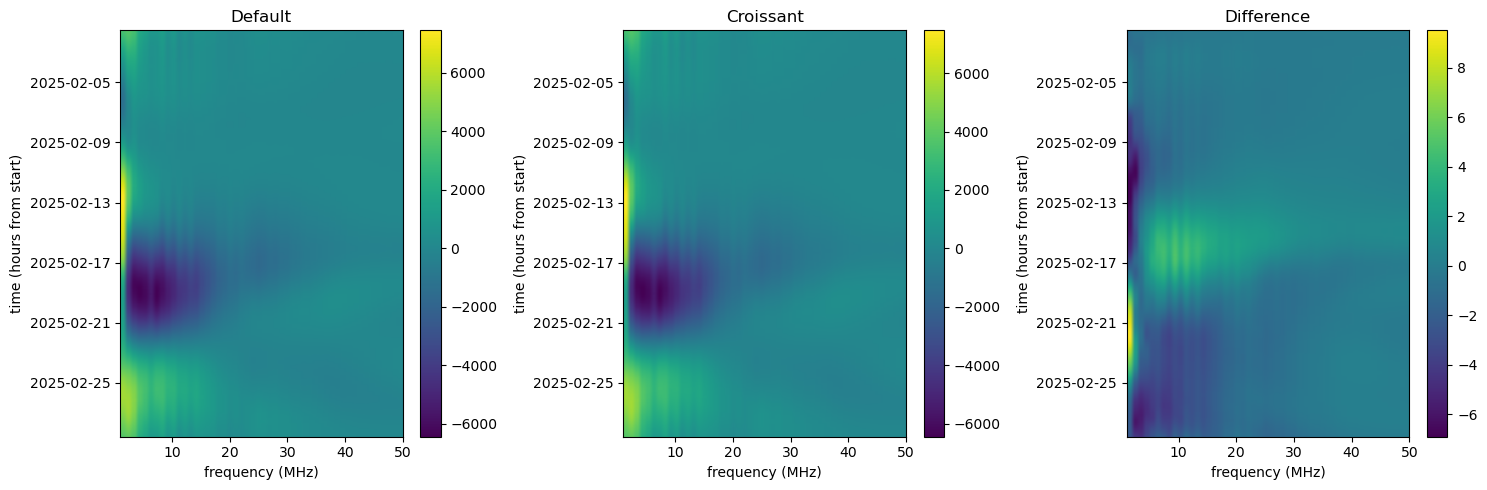

In [27]:
plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(D[:,'01I',:],aspect='auto',extent=(D.freq[0], D.freq[-1], time_default[-1], time_default[0]))
plt.colorbar()
plt.xlabel('frequency (MHz)')
plt.ylabel('time (hours from start)')
plt.title('Default')

plt.subplot(132)
plt.imshow(D_cro[:,'01I',:],aspect='auto',extent=(D_cro.freq[0], D_cro.freq[-1], time_cro[-1], time_cro[0]))
plt.colorbar()
plt.xlabel('frequency (MHz)')
plt.ylabel('time (hours from start)')
plt.title('Croissant')

plt.subplot(133)
plt.imshow(D[:,'01I',:] - D_cro[:,'01I',:],aspect='auto',extent=(D.freq[0], D.freq[-1], time_default[-1], time_default[0]))
plt.colorbar()
plt.xlabel('frequency (MHz)')
plt.ylabel('time (hours from start)')
plt.title('Difference')


plt.tight_layout()

In [28]:

D_avg = time_avg(D)
D_avg_cro = time_avg(D_cro)

In [29]:
D_avg.shape

(16, 50)

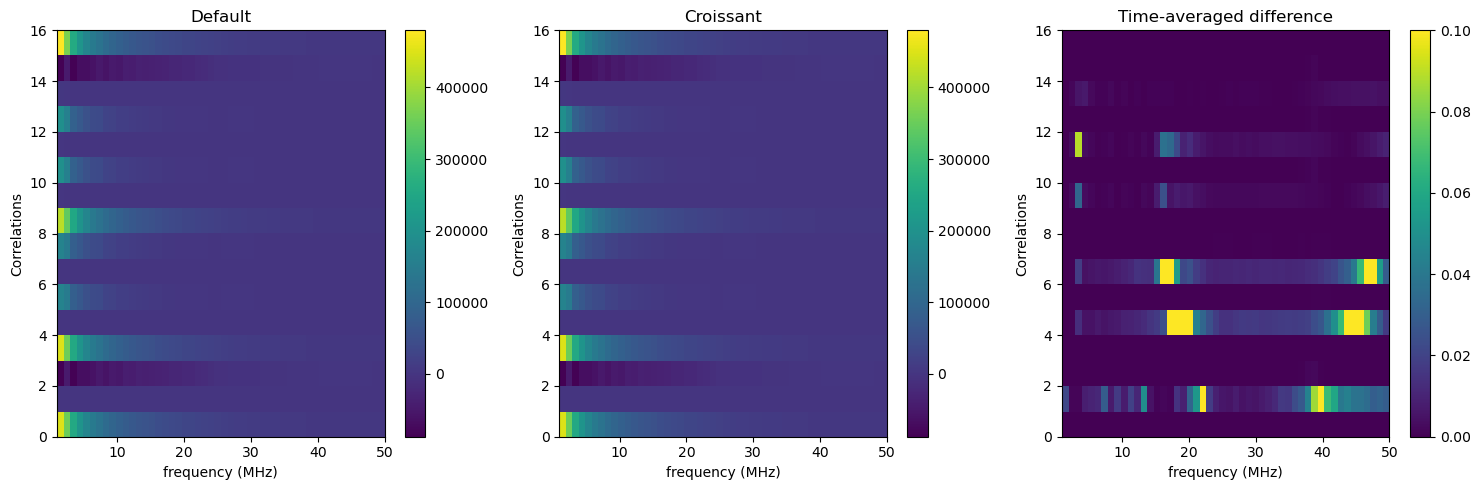

In [30]:
plt.figure(figsize=(15,5))
plt.subplot(131)
plt.imshow(D_avg, aspect='auto', extent=(D.freq[0], D.freq[-1], 0,16))
plt.xlabel('frequency (MHz)')
plt.ylabel('Correlations')
plt.title('Default')
plt.colorbar()

plt.subplot(132)
plt.imshow(D_avg_cro, aspect='auto', extent=(D.freq[0], D.freq[-1], 0,16))
plt.xlabel('frequency (MHz)')
plt.ylabel('Correlations')
plt.title('Croissant')
plt.colorbar()


plt.subplot(133)
plt.imshow(np.abs(D_avg-D_avg_cro)/np.abs(D_avg), aspect='auto', extent=(D.freq[0], D.freq[-1], 0,16), clim=([0,0.1]))
plt.colorbar()
plt.xlabel('frequency (MHz)')
plt.ylabel('Correlations')
plt.title('Time-averaged difference')
plt.tight_layout()



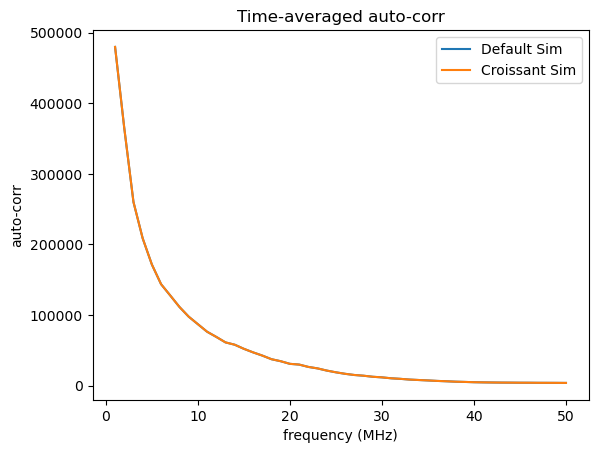

In [31]:
plt.plot(D.freq,D_avg[0], label='Default Sim')
plt.plot(D.freq,D_avg_cro[0], label='Croissant Sim')
plt.xlabel('frequency (MHz)')
plt.ylabel('auto-corr')
plt.title('Time-averaged auto-corr')
plt.legend()
plt.show()


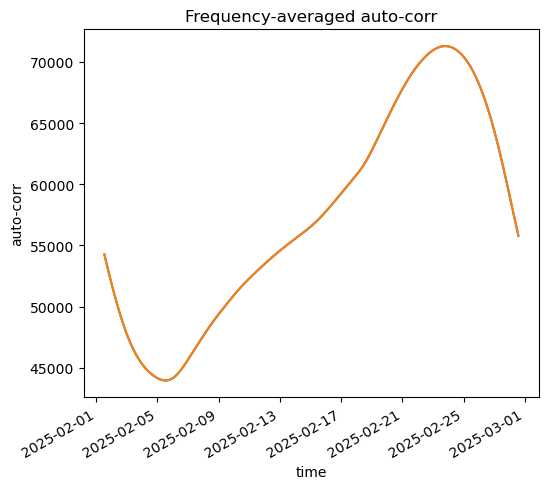

In [32]:
#freq avg
D_avg_freq = freq_avg(D)
D_avg_freq_cro = freq_avg(D_cro)

plt.figure(figsize=(15,5))
plt.subplot(131)
plt.plot(time_default, D_avg_freq[:,0], label='Default')
plt.plot(time_cro, D_avg_freq_cro[:,0], label='Croissant')
plt.xlabel('time')
plt.ylabel('auto-corr')
plt.gca().xaxis_date()  # interpret x as dates
plt.gcf().autofmt_xdate()  # tilt date labels
plt.title('Frequency-averaged auto-corr')
plt.tight_layout()

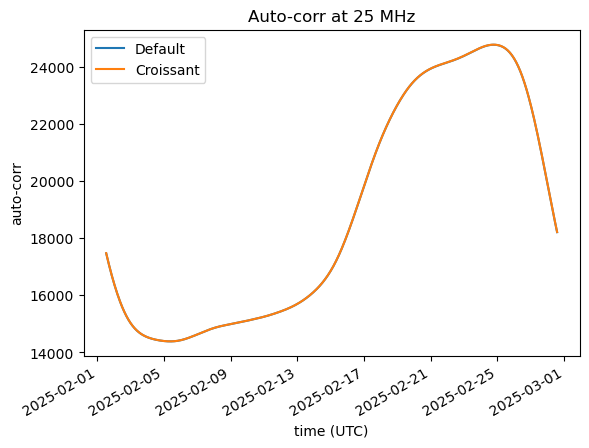

In [33]:
# auto-corr at 25 MHz (x-axis = calendar time from D.times Time object)

plt.plot(time_default, D.data[:,0,24], label='Default')
plt.plot(time_cro, D_cro.data[:,0,24], label='Croissant')
plt.xlabel('time (UTC)')
plt.ylabel('auto-corr')
plt.title('Auto-corr at 25 MHz')
plt.legend()
plt.gca().xaxis_date()  # interpret x as dates
plt.gcf().autofmt_xdate()  # tilt date labels
plt.show()

## display sky and beam for default and croissant






## Single pixel test

Parameters set: check `tests/test_lunar_day_sims.py`

Beam: 

    beam = lusee.BeamGauss(
        dec_deg=90.0,
        sigma_deg= 70,
        phi_deg=90.0,
        one_over_freq_scaling=False,
        id="beam",
    )

Sky:

    ecl_lon_deg, ecl_lat_deg = 45.0, 0.0
    ra_deg, dec_deg = _ecliptic_lon_lat_to_ra_dec_deg(ecl_lon_deg, ecl_lat_deg
    freq = np.arange(1, 51, 1, dtype=float)

    lusee.sky.SingleSourceHealpixSky(ra_deg, dec_deg, Nside=nside, freq=freq)

Obs: 

    time_start = "2025-03-01 00:00:00"
    time_end = "2025-03-29 00:00:00"  # 28 days later
    deltaT_sec = 7200.0  # 2 hours
    obs = lusee.Observation(
        f"{time_start} to {time_end}",
        deltaT_sec=deltaT_sec,
        lun_lat_deg=0.0,
        lun_long_deg=0.0,
    )


### Sky and beam comparison (Default vs Croissant)

**Default simulator** (sky and beam at 26 MHz):

![Default sky and beam](figures/sky_beam_healpix_default_single_pixel.png)

**Croissant simulator** (sky and beam at 26 MHz):

![Croissant sky and beam](figures/sky_beam_healpix_cro_single_pixel.png)

In [34]:
pwd

'/Users/akshatha.vydula/lusee/luseepy/simulation/output'

In [35]:
#single pixel test

D_single = lusee.Data('../../tests/sim_output_default_singlepixel_28days.fits')
D_single_cro = lusee.Data('../../tests/sim_output_cro_singlepixel_28days.fits')

time_single = Time(D_single.times)
time_single_cro = Time(D_single_cro.times)

time_single = time_single.datetime
time_single_cro = time_single_cro.datetime


In [36]:
D_single.data.shape

(337, 1, 10)

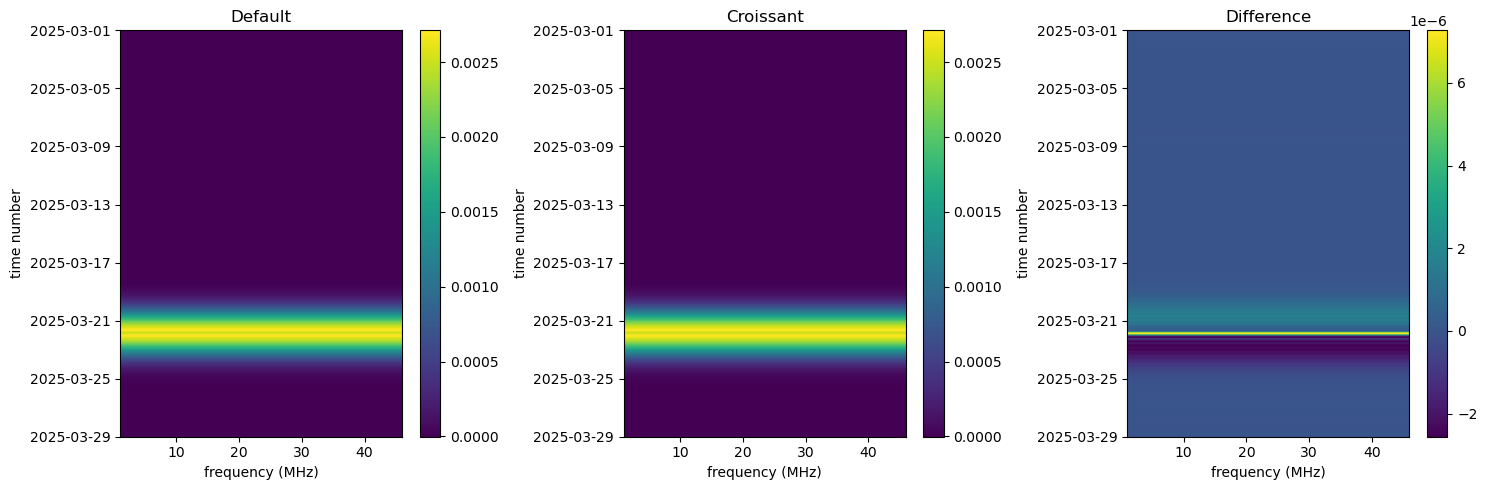

In [37]:
plt.figure(figsize=(15,5))
plt.subplot(131)
plt.imshow(D_single.data[:,0,:], aspect='auto', extent=(D_single.freq[0], D_single.freq[-1], time_single[-1], time_single[0]))
plt.xlabel('frequency (MHz)')
plt.ylabel('time number')
plt.title('Default')
plt.colorbar()

plt.subplot(132)
plt.imshow(D_single_cro.data[:,0,:], aspect='auto', extent=(D_single_cro.freq[0], D_single_cro.freq[-1], time_single_cro[-1], time_single_cro[0]))
plt.xlabel('frequency (MHz)')
plt.ylabel('time number')
plt.title('Croissant')
plt.colorbar()


plt.subplot(133)
plt.imshow(D_single.data[:,0,:]-D_single_cro.data[:,0,:], aspect='auto', extent=(D_single.freq[0], D_single.freq[-1], time_single[-1], time_single[0]))
plt.colorbar()
plt.xlabel('frequency (MHz)')
plt.ylabel('time number')
plt.title('Difference')
plt.tight_layout()

plt.tight_layout()

(337, 1) (10,) (337,)
Default max time:   2025-03-21 16:00:00 (value=0.00271203)
Croissant max time: 2025-03-21 16:00:00 (value=0.00271208)


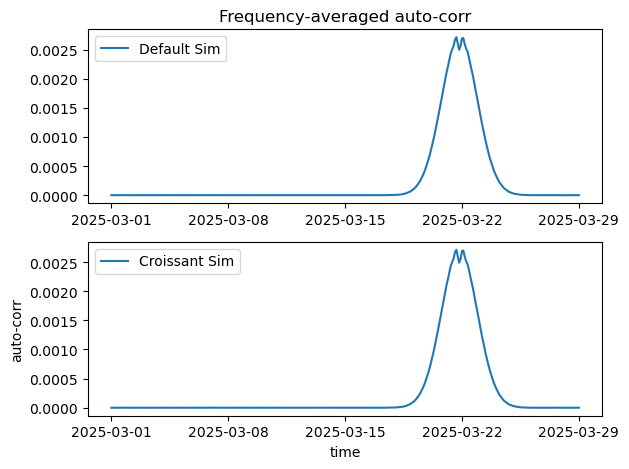

In [38]:
D_avg_single = freq_avg(D_single)
D_avg_single_cro = freq_avg(D_single_cro)

print(D_avg_single.shape, D_single.freq.shape, D_single.times.shape)
tick_idx = np.linspace(0, len(time_single)-1, 5, dtype=int)
plt.subplot(211)
plt.plot(time_single, D_avg_single[:,0], label='Default Sim')
plt.title('Frequency-averaged auto-corr')
plt.legend()
plt.xticks(time_single[tick_idx])


plt.subplot(212)
plt.plot(time_single_cro, D_avg_single_cro[:,0], label='Croissant Sim')
plt.xlabel('time')


plt.xticks(time_single[tick_idx])
plt.ylabel('auto-corr')

plt.legend()
plt.tight_layout()
imax_default = np.argmax(D_avg_single[:, 0])
imax_cro = np.argmax(D_avg_single_cro[:, 0])

print(f"Default max time:   {time_single[imax_default]} (value={D_avg_single[imax_default, 0]:.6g})")
print(f"Croissant max time: {time_single_cro[imax_cro]} (value={D_avg_single_cro[imax_cro, 0]:.6g})")

In [39]:
time_start = "2025-03-01 00:00:00"
time_end = "2025-03-29 00:00:00"  # 28 days later
deltaT_sec = 7200.0  # 2 hours
obs = lusee.Observation(
        f"{time_start} to {time_end}",
        deltaT_sec=deltaT_sec,
        lun_lat_deg=0.0,
        lun_long_deg=0.0,
    )


In [40]:
from astropy.coordinates import SkyCoord, GeocentricMeanEcliptic
from astropy import units as u
ecl_lon_deg, ecl_lat_deg = 90.0, 00.0
c = SkyCoord(lon=ecl_lon_deg * u.deg, lat=ecl_lat_deg * u.deg, frame=GeocentricMeanEcliptic)
ra_deg, dec_deg = c.icrs.ra.deg, c.icrs.dec.deg
l_deg, b_deg = c.galactic.l.deg, c.galactic.b.deg

In [41]:
alt,az = obs.get_track_ra_dec(ra_deg, dec_deg)
alt_alt,az_alt = obs.get_track_l_b(l_deg, b_deg)

2025-03-21 20:00:00.000


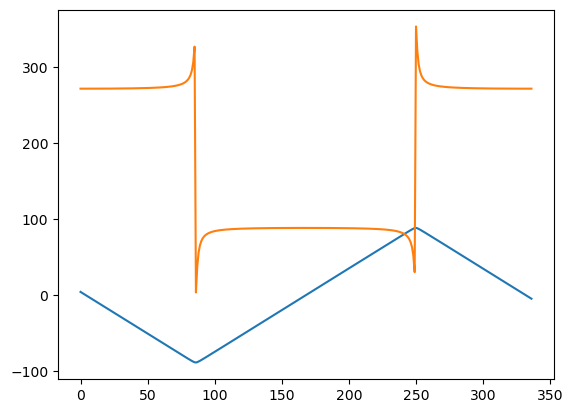

In [42]:


alt_deg = np.rad2deg(alt.to_value(u.rad) if hasattr(alt, "to_value") else np.asarray(alt, dtype=float))
az_deg = np.rad2deg(az.to_value(u.rad) if hasattr(az, "to_value") else np.asarray(az, dtype=float))
plt.plot(alt_deg, label='alt')
plt.plot(az_deg, label='az')
#plt.plot(alt_alt/np.pi*180, label='alt_alt')
print (obs.times[alt.argmax()])

In [43]:
# Find times when altitude crosses 60 deg (rising or falling)

alt_track, _ = obs.get_track_ra_dec(ra_deg, dec_deg)
alt_deg = np.rad2deg(alt_track.to_value(u.rad) if hasattr(alt_track, "to_value") else np.asarray(alt_track, dtype=float))

t_unix = Time(obs.times).unix
threshold = 60.0
y = alt_deg - threshold

crossings = []
for i in range(len(y) - 1):
    y0, y1 = y[i], y[i + 1]
    a0, a1 = alt_deg[i], alt_deg[i + 1]

    # Exact hit on sample
    if y0 == 0:
        direction = "raising" if (a1 - a0) > 0 else "falling"
        crossings.append((Time(t_unix[i], format="unix").datetime, direction))
        continue

    # Sign change between samples => crossing
    if y0 * y1 < 0:
        frac = (threshold - a0) / (a1 - a0)  # linear interpolation in interval
        t_cross = t_unix[i] + frac * (t_unix[i + 1] - t_unix[i])
        direction = "raising" if (a1 - a0) > 0 else "falling"
        crossings.append((Time(t_cross, format="unix").datetime, direction))

for t, d in crossings:
    print(f"{t}  ({d})")

2025-03-19 13:05:35.379896  (raising)
2025-03-24 02:14:23.510705  (falling)
